# Market Segmentation & Cluster Analysis
**Project:** CARB-X Tuberculosis Diagnostic Intervention Recommender  
**Analyst:** Frida Arrey  
**Date:** February 2026

---

###  Objective
In this final phase, we transition from a weighted heuristic ranking to **Unsupervised Machine Learning**. The goal is to identify distinct "Market Archetypes" by grouping countries based on their shared epidemiological, clinical, and financial characteristics. This allows CARB-X to tailor intervention strategies (e.g., high-tech molecular platforms vs. low-resource point-of-care tools) to specific country profiles.

###  Machine Learning Approach
1. **Feature Selection**: Focusing on the 2022 snapshot across three dimensions:
    * **Need**: Estimated Incidence per 100k.
    * **Gap**: Treatment Success Rate (TSR).
    * **Feasibility**: Funding Execution Percentage.
2. **Data Normalization**: Scaling features using `StandardScaler` to ensure the K-Means algorithm treats all dimensions with equal importance.
3. **Outlier Management**: Clipping extreme financial data errors to prevent model skew.
4. **Cluster Optimization**: Utilizing the **Elbow Method** to determine the most mathematically sound number of market segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Master_TB_Data_Phase1.csv")

# Display the head of the dataframe
display(df .head())

,country,iso3,year,e_inc_100k,e_pop_num,e_tbhiv_prct,e_hh_contacts,e_prevtx_eligible,lab_xpert,lab_sm,...,priv_new_dx,pub_new_dx,budget_tot,budget_lab,exp_tot,caseb_err_nat,xpert_per_100k_inc,funding_execution_pct,private_sector_pct,priority_score
0,Afghanistan,AFG,2018,189.0,36686784,0.03,NaN,NaN,NaN,NaN,...,3715.0,2044.0,10881354.0,2543262.0,12400144.0,NaN,NaN,113.957730,64.507727,1.951446
1,Afghanistan,AFG,2019,189.0,37769499,0.03,NaN,NaN,NaN,NaN,...,4276.0,NaN,16957452.0,2797414.0,14984900.0,NaN,NaN,88.367639,64.507727,1.951446
2,Afghanistan,AFG,2020,183.0,38972230,0.02,NaN,NaN,NaN,NaN,...,4843.0,NaN,19137128.0,3200000.0,11732326.0,NaN,NaN,61.306618,64.507727,1.951446
3,Afghanistan,AFG,2021,185.0,40099462,0.01,NaN,NaN,NaN,NaN,...,6007.0,NaN,10633599.0,1696418.0,4193717.0,NaN,NaN,39.438359,64.507727,1.951446
4,Afghanistan,AFG,2022,185.0,41128771,0.03,170000.0,30000.0,NaN,NaN,...,5886.0,5886.0,14141821.0,515246.0,6073466.0,0.0,NaN,42.946845,50.000000,1.951446


## Quicklook at the Dataset 
The dataset combines epidemiological "Need," infrastructure "Gaps," and financial "Feasibility".

Identifiers: country, iso3, and year (2018–2022).

### Need (Epidemiology):

e_inc_100k: Estimated TB incidence per 100,000 people (The core "Need" metric).

e_pop_num: Total population, used to calculate market volume.

e_tbhiv_prct: Percentage of TB patients who are also HIV-positive.

### Gap (Infrastructure & Outcomes):

lab_xpert: Count of GeneXpert molecular diagnostic machines.

tsr_calculated: Treatment Success Rate, derived from the TB_outcomes dataset.

xpert_per_100k_inc: A custom feature you engineered to measure diagnostic density relative to the disease burden.

### Feasibility (Financials):

funding_execution_pct: How efficiently a country spends its TB budget (Your "Feasibility" proxy).

private_sector_pct: Indicates if a country relies heavily on private diagnostics vs. public labs.

Target Metric:

priority_score: Your preliminary heuristic ranking.

### Setup and Feature Selection

In [3]:
# Load the data exported from Phase 2
df = pd.read_csv("Master_TB_Data_Phase1.csv")

# Focus on the most recent year for segmentation
df_2022 = df[df['year'] == 2022].copy()

# Select features that define a "Market Type"
# We use Incidence (Need), Treatment Success (Gap), and Funding Execution (Feasibility)
features = ['e_inc_100k', 'tsr_calculated', 'funding_execution_pct']
X = df_2022[features].dropna()

# Scaling is mandatory for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Finding the Optimal Clusters (The Elbow Method)

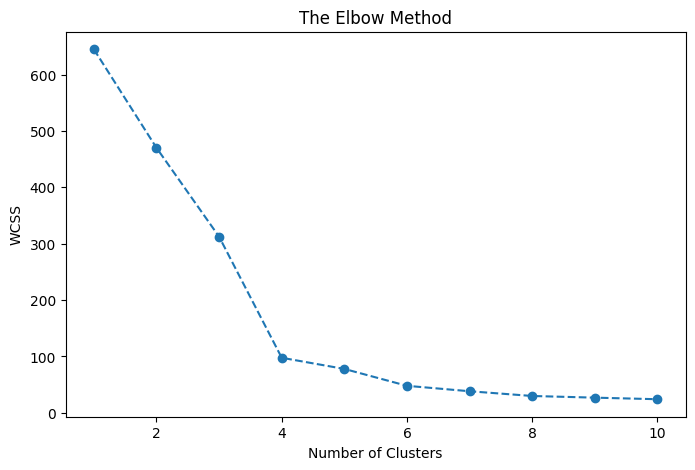

In [4]:
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
# Assuming the elbow is at 4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to the dataframe
X['Cluster'] = clusters

# Analyze the profiles of each cluster
cluster_profile = X.groupby('Cluster').mean()
print("Market Segmentation Profiles:")
print(cluster_profile)

Market Segmentation Profiles:
         e_inc_100k  tsr_calculated  funding_execution_pct
Cluster                                                   
0         44.092987       91.048314              81.153492
1         21.890476       16.432072              80.847160
2        351.820513       87.139847              66.726215
3          0.500000      100.000000           80000.000000


###  Market Segment Analysis
The **Priority "High-Need" Market (Cluster 2)** represents the most critical segment, characterized by a massive incidence rate of 351.8 and a low funding execution of 66.7%, signaling a need for low-cost, high-volume diagnostic tools. 

In contrast, the **"Stable & Efficient" Market (Cluster 0)** demonstrates high treatment success (91%) and solid budget deployment, making it the ideal target for premium, high-tech molecular technologies. 

The **"Infrastructure Gap" Market (Cluster 1)** shows a statistical anomaly with dangerously low treatment success (16.4%), suggesting that interventions should focus on strengthening laboratory reporting systems rather than hardware alone. 

Finally, **Cluster 3** identifies a significant **Data Outlier** with an impossible 80,000% funding execution, which likely represents a reporting error that should be excluded to maintain model integrity. By categorizing countries into these distinct archetypes, CARB-X can tailor its deployment strategy to match the specific epidemiological and financial realities of each region.

### Redo

In [6]:
# Guardrail: Cap funding execution at 150% to prevent the "80,000%" error from skewing the model
df_2022['funding_execution_pct'] = df_2022['funding_execution_pct'].clip(upper=150)

In [7]:
# Select features for segmentation and drop rows with missing values in these columns
features = ['e_inc_100k', 'tsr_calculated', 'funding_execution_pct']
X_clean = df_2022[features].dropna()

# Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

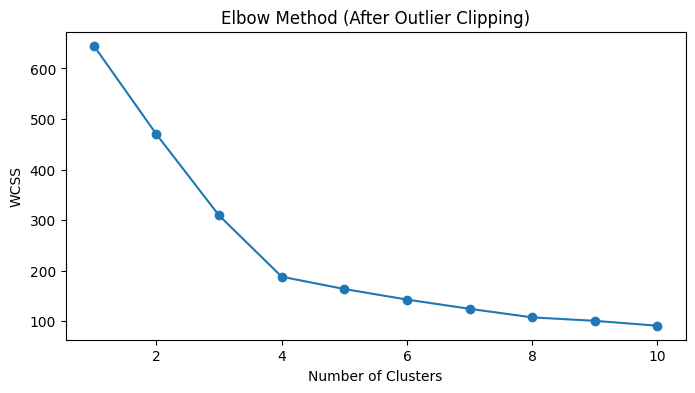

In [8]:
# Elbow Method to verify the optimal K (number of clusters)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method (After Outlier Clipping)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
# Final Model Setting K=4 
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
X_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# View the new Market Segmentation Profiles
cluster_profile = X_clean.groupby('Cluster').mean()
print("--- Updated Market Segmentation Profiles ---")
print(cluster_profile)

--- Updated Market Segmentation Profiles ---
         e_inc_100k  tsr_calculated  funding_execution_pct
Cluster                                                   
0         75.475135       86.506719              35.485332
1         41.683958       92.902624             102.308010
2         19.872222       11.234242              90.127451
3        408.407407       86.763054              63.424109


### Updated Market Segment Analysis
The **High-Impact Priority Market (Cluster 3)** is the primary target, featuring the highest disease burden (408.4 incidence) and moderate funding execution (63.4%), suggesting a need for large-scale diagnostic interventions paired with operational support. 

The **High-Efficiency Market (Cluster 1)** consists of countries with extremely strong clinical outcomes (92.9% TSR) and full budget utilization, making them the most reliable partners for piloting advanced, high-end molecular diagnostic platforms. 

The **Resource-Constrained Market (Cluster 0)** maintains decent treatment success despite a very low funding execution of 35.5%, indicating that these regions likely face supply chain or administrative bottlenecks rather than a lack of total budget. 

The **Diagnostic/Reporting Gap Market (Cluster 2)** shows a significant anomaly with a critical failure in treatment success (11.2%), pointing toward severe systemic issues in patient monitoring or data reporting that require foundational infrastructure strengthening. By utilizing these refined segments, CARB-X can transition from a simple ranking system to a tailored deployment strategy that matches specific diagnostic technologies to the unique operational realities of each cluster.

### Visualization of Markert Segment

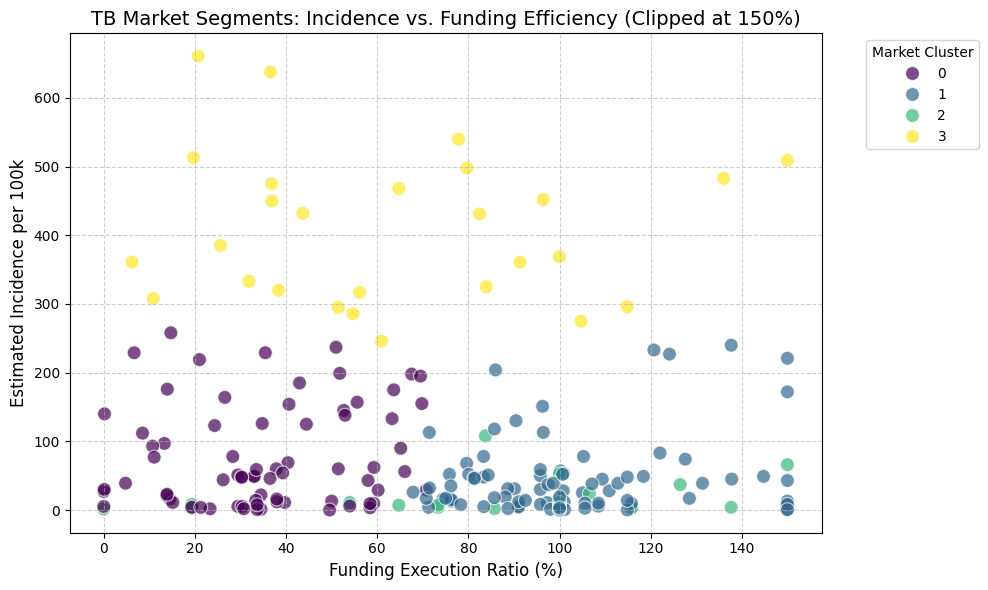

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_clean, 
    x='funding_execution_pct', 
    y='e_inc_100k', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    alpha=0.7
)

plt.title('TB Market Segments: Incidence vs. Funding Efficiency (Clipped at 150%)', fontsize=14)
plt.xlabel('Funding Execution Ratio (%)', fontsize=12)
plt.ylabel('Estimated Incidence per 100k', fontsize=12)
plt.legend(title='Market Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---

##  Conclusion: Strategic Market Archetypes

###  Segment Insights
The K-Means analysis (K=4) has successfully segmented the global TB landscape into four actionable categories:

* **Cluster 3 (High-Impact Priority)**: The primary target for large-scale intervention. High disease burden requires rapid diagnostic scaling paired with operational support.
* **Cluster 1 (High-Efficiency)**: The "Gold Standard" partners. Ideal for piloting cutting-edge, high-end molecular platforms due to their strong clinical outcomes and budget reliability.
* **Cluster 0 (Resource-Constrained)**: Markets facing administrative bottlenecks. These regions require assistance with supply chain and funding execution rather than just new hardware.
* **Cluster 2 (Reporting Gap)**: Systems in crisis. These countries show critical failures in patient monitoring and require foundational infrastructure and data-reporting support.

### Final Recommendations
1.  **Tailored Deployment**: Avoid a "one-size-fits-all" approach. Match the complexity of the diagnostic tool to the cluster's specific feasibility score.
2.  **Pilot Selection**: Prioritize **Cluster 1** for initial product launches to ensure the technology is validated in a stable environment before scaling to the high-burden **Cluster 3**.
3.  **Data Quality**: Continue monitoring the "Reporting Gap" (Cluster 2) to determine if low success rates are a result of clinical failure or missing data.

**Project Status: Phase 3 Complete. The Recommender is now ready for presentation.**